# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [ ]:
''' 
Las principales diferencias que encontre entre esos dos diferentes codificadores son que:
1. LabelEncoder asigna un numero unico a cada categoria a comparacion de OneHotEncoder que crea una columna binaria independiente para cada categoria.
2. LabelEncoder transforma los valores en la misma columna mientras que OneHotEncoder no, este si aumenta las columnas de acuerdo a las categorias.
3. Para LabelEncoder un uso ideal es usarlo con valores ordinales donde el orden tiene importancia, OneHotEncoder se recomienda para variables tienen el mismo valor 
o bien no importa el valor.
'''

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

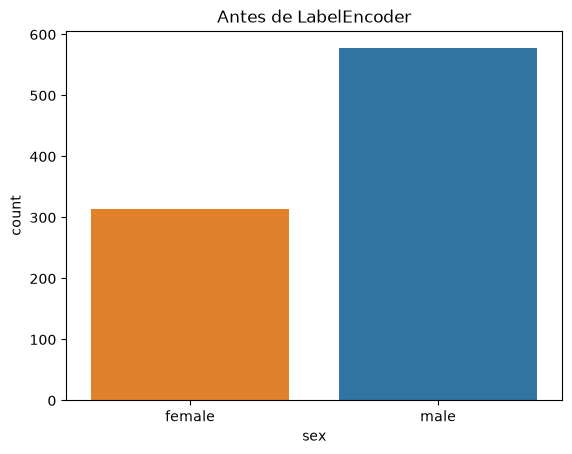

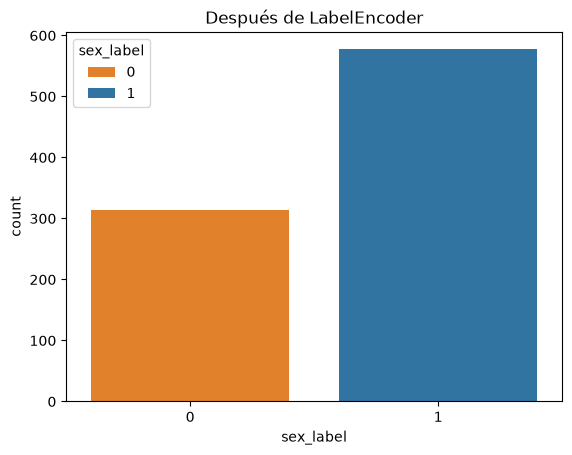

In [8]:
plt.figure()
sns.countplot(data=data, x='sex',hue='sex', order=['female', 'male'])
plt.title('Antes de LabelEncoder')
plt.show()

plt.figure()
sns.countplot(data=data, x='sex_label',hue='sex_label',palette=['#ff7f0e', '#1f77b4'])
plt.title('Después de LabelEncoder')
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [9]:
data['class_label']=label_encoder.fit_transform(data['class'])
data.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_label,embarked_C,embarked_Q,embarked_S,class_label
629,0,3,male,NaN,0,0,7.7333,Q,Third,man,True,NaN,Queenstown,no,True,1,False,True,False,2
825,0,3,male,NaN,0,0,6.9500,Q,Third,man,True,NaN,Queenstown,no,True,1,False,True,False,2
253,0,3,male,30.0,1,0,16.1000,S,Third,man,True,NaN,Southampton,no,False,1,False,False,True,2
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True,1,True,False,False,2
364,0,3,male,NaN,1,0,15.5000,Q,Third,man,True,NaN,Queenstown,no,False,1,False,True,False,2


In [ ]:
'''
La ventajas que tiene utilizar Label Encoder frente a OneHotEncoder es como lo mencione con anterioridad es el uso del mismo. 
En este caso como estamos trabajando con clases(sociales) aqui innfluye mucho sus categorias dado que dependiendo de ellas les daba acceso a 
una mejor zona o no. Por lo cual, el uso de Label encoder nos ayuda a definir su prioridad con los numero enteros que se les asigna, por el
contrario haber trabajado con OneHotEncoder hubiera transformado la columan en 0 y 1 lo cual indicaria que no hay ninguna diferencia entre ellas
y el modelo podria predecir mal los resultados.
'''

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
'''
Elegir alguno de los dos sin el contexto completo sobre las columnas es dificil de decidir. Sin embargo, si estamos hablando de variable
categoricas con un orden de jerarquia me parece que la mejor opcion es Label Encoder por el contrario si hablamos de variables categoricas
que no importa tal y como podria ser colores, generos o algo por el estilo la mejor eleccion puede ser OneHotEncoder
'''